In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [2]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.utils import save_image
import numpy as np
import datetime
import os, sys
from matplotlib.pyplot import imshow, imsave
%matplotlib inline

In [3]:
class Discriminator(nn.Module):
    """
        Simple Discriminator w/ MLP
    """
    def __init__(self, num_classes=1):
        super(Discriminator, self).__init__()
        self.layer1 = nn.Sequential(#32*32*3 -> 16*16*64
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU())
        self.layer2 = nn.Sequential(#16*16*64 -> 8*8*64
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU())
        self.layer3 = nn.Sequential(#8*8*64 -> 4*4*128
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias = False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),#4*4*128 -> 2*2*128
            nn.AvgPool2d(kernel_size = 2, stride = 1)#2*2*128 -> 1*1*128
            )
        self.layer4 = nn.Sequential(
            nn.Linear(128, 1024),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.5),
            nn.ReLU())
        self.layer5= nn.Sequential(
            nn.Linear(1024, num_classes),
            nn.Sigmoid(),)
    def forward(self, x):
        y = self.layer1(x)
        y = self.layer2(y)
        y = self.layer3(y)
        y = y.view(y.size(0), -1)
        y = self.layer4(y)
        y = self.layer5(y)    
        return y

In [4]:
class Generator(nn.Module):
    """
        Simple Generator w/ MLP
    """
    def __init__(self, input_size=100):
        super(Generator, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU())  
        self.layer2 = nn.Sequential(
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU())
        self.layer3 = nn.Sequential(
            nn.Linear(1024, 8*8*128),
            nn.BatchNorm1d(8*8*128),
            nn.ReLU())
        self.layer4 = nn.Sequential(#8*8*128 -> 16*16*128
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.layer5 = nn.Sequential(#16*16*128 -> 32*32*3
            nn.ConvTranspose2d(128, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh())

        
    def forward(self, x):
        y = self.layer1(x)
        y = self.layer2(y)
        y = self.layer3(y)
        y = y.view(y.size(0), 128, 8, 8)
        y = self.layer4(y)
        y = self.layer5(y)
        return y

In [5]:
n_noise = 100

In [19]:
DEVICE = "cuda"

In [20]:
D = Discriminator().to(DEVICE)
G = Generator(n_noise).to(DEVICE)

In [8]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5],
                                std=[0.5])]
)

In [9]:
cifar = datasets.CIFAR10(root='../data/cifar', train=True, transform=transform, download=True)

Files already downloaded and verified


In [10]:
batch_size = 64

In [11]:
data_loader = DataLoader(dataset=cifar, batch_size=batch_size, shuffle=True, drop_last=True)

In [39]:
# def get_sample_image(G, n_noise):
#     """
#         save sample 100 images
#     """
#     z = torch.randn(100, n_noise).to(DEVICE)
#     print(z.shape)
#     y_hat = G(z)
#     print(y_hat.shape)
#     y_hat = y_hat.view(100, 3, 32, 32)
#     print(y_hat.shape)
#     result = y_hat.cpu().data.numpy()
#     img = np.zeros([3,320, 320])
#     for j in range(10):
#         img[j*32:(j+1)*32] = np.concatenate([x for x in result[j*10:(j+1)*10]], axis=-1)
#     return img
import numpy as np
import torch

def get_sample_image(G, n_noise):
    """
    Generate and return a grid of sample images from the generator.
    """
    # Generate noise
    z = torch.randn(100, n_noise).to(DEVICE)
    # print(z.shape)
    
    # Generate images
    y_hat = G(z)
    # print(y_hat.shape)
    
    # Reshape to (100, 3, 32, 32) for RGB images
    y_hat = y_hat.view(100, 3, 32, 32)
    # print(y_hat.shape)
    
    # Move to CPU and convert to numpy
    result = y_hat.cpu().data.numpy()
    
    # Create an empty grid to hold the output image (3 channels, 320x320)
    img = np.zeros([3, 320, 320])
    
    for j in range(10):
        # Concatenate 10 images horizontally along the width (axis=-1)
        row = np.concatenate(result[j*10:(j+1)*10], axis=-1)  # Shape: (3, 32, 320)
        # Place the concatenated row into the grid
        img[:, j*32:(j+1)*32, :] = row  # Assign to the corresponding position in the grid
    
    # Transpose the grid to (320, 320, 3) for visualization (H, W, C)
    img = img.transpose(1, 2, 0)
    img = (img + 1) / 2  # Normalize from [-1, 1] to [0, 1]

    return img


In [13]:
for x,y in data_loader:
    print(x.shape, y.shape)
    break
#so its made of rgb 32 by 32 images

torch.Size([64, 3, 32, 32]) torch.Size([64])


In [21]:
criterion = nn.MSELoss()
D_opt = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
G_opt = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
max_epoch = 100 # need more than 10 epochs for training generator
step = 0
n_critic = 1 # for training more k steps about Discriminator
D_labels = torch.ones(batch_size, 1).to(DEVICE) # Discriminator Label to real
D_fakes = torch.zeros(batch_size, 1).to(DEVICE) # Discriminator Label to fake


In [15]:
if not os.path.exists('cifar_gan'):
    os.makedirs('cifar_gan')

In [40]:
step =0
for epoch in range(max_epoch):
    for idx, (images, _) in enumerate(data_loader):
        # Training Discriminator
        x = images.to(DEVICE)
        x_outputs = D(x)
        D_x_loss = criterion(x_outputs, D_labels)

        z = torch.randn(batch_size, n_noise).to(DEVICE)
        z_outputs = D(G(z))
        D_z_loss = criterion(z_outputs, D_fakes)
        D_loss = D_x_loss + D_z_loss
        
        D.zero_grad()
        D_loss.backward()
        D_opt.step()
        if step % n_critic == 0:
            # Training Generator
            z = torch.randn(batch_size, n_noise).to(DEVICE)
            z_outputs = D(G(z))
            G_loss = criterion(z_outputs, D_labels)

            D.zero_grad()
            G.zero_grad()
            G_loss.backward()
            G_opt.step()
        
        if step % 500 == 0:
            print('Epoch: {}/{}, Step: {}, D Loss: {}, G Loss: {}'.format(epoch, max_epoch, step, D_loss.item(), G_loss.item()))
        
        if step % 1000 == 0:
            G.eval()
            img = get_sample_image(G, n_noise)
            imsave('cifar_gan/{}_step{}.jpg'.format("cifar_generations", str(step).zfill(3)), img, cmap='gray')
            G.train()
        step += 1

Epoch: 0/100, Step: 0, D Loss: 0.11162186414003372, G Loss: 0.8344063758850098
Epoch: 0/100, Step: 500, D Loss: 0.15548580884933472, G Loss: 0.8706353902816772
Epoch: 1/100, Step: 1000, D Loss: 0.4048923850059509, G Loss: 0.35789060592651367
Epoch: 1/100, Step: 1500, D Loss: 0.46951690316200256, G Loss: 0.5752915143966675
Epoch: 2/100, Step: 2000, D Loss: 0.12887924909591675, G Loss: 0.856278657913208
Epoch: 3/100, Step: 2500, D Loss: 0.10127691179513931, G Loss: 0.9147425889968872
Epoch: 3/100, Step: 3000, D Loss: 0.21149224042892456, G Loss: 0.7856591939926147
Epoch: 4/100, Step: 3500, D Loss: 0.07038464397192001, G Loss: 0.9390411376953125
Epoch: 5/100, Step: 4000, D Loss: 0.10639917105436325, G Loss: 0.8620065450668335
Epoch: 5/100, Step: 4500, D Loss: 0.07083112001419067, G Loss: 0.9394256472587585
Epoch: 6/100, Step: 5000, D Loss: 0.03897877410054207, G Loss: 0.942167341709137
Epoch: 7/100, Step: 5500, D Loss: 0.41429826617240906, G Loss: 0.9721145033836365
Epoch: 7/100, Step: 60

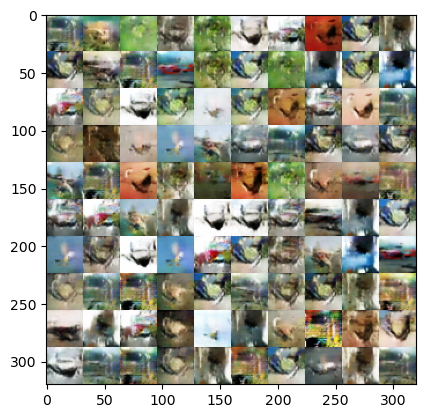

In [42]:
G.eval()
imshow(get_sample_image(G, n_noise))

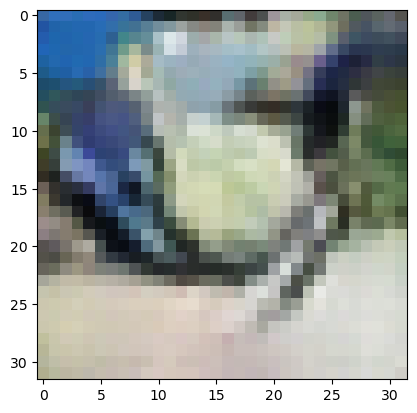

In [69]:
# Generate noise
z = torch.randn(1,n_noise).to(DEVICE)
# print(z.shape)

# Generate images
y_hat = G(z)
# print(y_hat.shape)

# Reshape to (100, 3, 32, 32) for RGB images
# y_hat = y_hat.view(100, 3, 32, 32)
# print(y_hat.shape)

# Move to CPU and convert to numpy
result = y_hat.cpu().data.numpy()

# Create an empty grid to hold the output image (3 channels, 320x320)
# img = np.zeros([3, 320, 320])

# for j in range(10):
#     # Concatenate 10 images horizontally along the width (axis=-1)
#     row = np.concatenate(result[j*10:(j+1)*10], axis=-1)  # Shape: (3, 32, 320)
#     # Place the concatenated row into the grid
#     img[:, j*32:(j+1)*32, :] = row  # Assign to the corresponding position in the grid

# Transpose the grid to (320, 320, 3) for visualization (H, W, C)
# img = img.transpose(1, 2, 0)
# img = (img + 1) / 2  # Normalize from [-1, 1] to [0, 1]
# result = result.transpose(1, 2, 0)
result = (result + 1) / 2  # Normalize from [-1, 1] to [0, 1]
result = result.squeeze()
result = result.transpose(1, 2, 0)
imshow(result)
